# California Housing: A Multi-Model Regression Benchmark

### Mastering End-to-End Predictive Modeling with Scikit-Learn Pipelines and Ensemble Methods

---

## Project Metadata

* **Author:** [Prajwal Kedari](https://www.github.com/prajwalkedari)
* **Dataset:** [California Housing Prices (1990 Census)](https://www.kaggle.com/datasets/camnugent/california-housing-prices)
* **Problem Type:** Supervised Learning (Regression)

**Objective:**
To develop a robust and scalable machine learning pipeline for housing price prediction, and to benchmark multiple regression algorithms to identify the most effective model.

---

## Project Overview

This notebook presents a comprehensive machine learning workflow, including:

* Exploratory Data Analysis (EDA) to understand feature behavior
* Feature engineering to enhance predictive signals
* Construction of a reusable preprocessing pipeline
* Benchmarking of 20+ regression models
* Hyperparameter tuning of top-performing models
* Comparative evaluation using R² score

---

## Key Highlights

* Evaluated 20+ regression models across different algorithm families
* Implemented a complete preprocessing pipeline using Scikit-Learn
* Applied feature engineering to improve model performance
* Performed hyperparameter tuning for optimized results
* Achieved best performance using XGBoost (~0.81 R² score)

---

## Dataset Description

The dataset contains housing information across various districts in California, including:

* **Geographical Features:** Latitude, Longitude
* **Demographic Features:** Population, Households
* **Economic Indicators:** Median Income
* **Structural Attributes:** Total Rooms, Bedrooms

**Target Variable:**

* `median_house_value`

---

# Table of Contents
## Table of Contents

### 1. [Introduction](#California-Housing:-A-Multi-Model-Regression-Benchmark)

### 2. [Environment Setup and Library Imports](#1.-Import-Libraries)

### 3. [Exploratory Data Analysis (EDA)](#3.-Exploratory-Data-Analysis-%28EDA%29)

* 3.1 [Ocean Proximity Distribution](#3.1-Ocean-Proximity-Distribution)
* 3.2 [Statistical Summary](#3.2-Statistical-Summary)

### 4. [Data Visualization](#4.-Data-Visualization)

* 4.1 [Feature Distribution Analysis](#4.1-Feature-Distribution-Analysis)
* 4.2 [Key Observations](#4.2-Key-Observations)

### 5. [Income Analysis](#5.-Income-Analysis)

### 6. [Stratified Sampling](#6.-Stratified-Spliting-Sampling-⚖️)

### 7. [Geographical Visualization](#7.-Geographical-Visualization)

### 8. [Correlation Analysis](#8.-Correlation-Analysis)

### 9. [Feature Engineering](#9.-Feature-Engineering)

### 10. [Data Preparation](#10.-Data-Preparation-for-Machine-Learning)

### 11. [Data Cleaning](#11.-Data-Cleaning)

### 12. [Data Preprocessing Pipeline](#12.-Data-Preprocessing-Pipeline)

### 13. [Model Training](#13.-Model-Training)

* 13.1 [Training Strategy](#13.1-Training-Strategy)
* 13.2 [Model Performance Results](#13.2-Model-Performance-Results)
* 13.3 [Performance Ranking](#13.3-Performance-Ranking)
* 13.4 [Saving Predictions](#13.4-Saving-Predictions)

### 14. [Model Optimization](#14.-Model-Optimization)

* 14.1 [XGBRegressor](#14.1-XGBRegressor)
* 14.2 [RandomForestRegressor](#14.2-RandomForestRegressor)
* 14.3 [GradientBoostingRegressor](#14.3-GradientBoostingRegressor)
* 14.4 [ExtraTreesRegressor](#14.4-ExtraTreesRegressor)

### 15. [Hyperparameter Tuning Results](#15.-Hyperparameter-Tuning-Results)

* 15.1 [Performance After Tuning](#15.1-Performance-After-Tuning)

### 16. [Model Performance Visualization](#16.-Model-Performance-Visualization)

* 16.1 [Performance Comparison Insights](#16.1-Performance-Comparison-Insights)
* 16.2 [Positive vs Negative Performance](#16.2-Positive-vs-Negative-Performance)
* 16.3 [Predictions vs Actual Values](#16.3-Predictions-vs-Actual-Values)
* 16.4 [Prediction Error Analysis](#16.4-Prediction-Error-Analysis)
* 16.5 [Model Agreement Analysis](#16.5-Model-Agreement-Analysis)

### 17. [Final Conclusion](#17.-Final-Conclusion)

## Project Scope

This notebook demonstrates a complete and production-ready machine learning workflow:

Data Exploration → Feature Engineering → Model Training → Optimization → Deployment

The objective is not only to build accurate models, but also to establish a structured and reproducible approach for solving real-world regression problems.


# 1. Import Libraries 
We begin by importing the required libraries for:

- Data manipulation → pandas, numpy  
- Data visualization → matplotlib, seaborn  
- Machine learning → scikit-learn, xgboost  

These libraries provide the necessary tools for building and evaluating machine learning models.

In [1]:
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit ,GridSearchCV
from sklearn.metrics import accuracy_score,r2_score
from sklearn import ensemble
from sklearn import gaussian_process
from sklearn import linear_model
from sklearn import naive_bayes
from sklearn import neighbors
from sklearn import svm
from sklearn import tree
from sklearn import discriminant_analysis
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib

import warnings
from sklearn.exceptions import ConvergenceWarning

# 2. Loading Dataset
The dataset is loaded using Pandas.<br>
We preview the dataset using `.head()`.

In [2]:

housing = pd.read_csv("/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


##  2.1 Dataset Overview
The California Housing dataset contains information about housing blocks in California.

### 🎯 Target Variable:
- `median_house_value`

### 📊 Key Features:
- Location → Latitude, Longitude  
- Demographics → Population, Households  
- Economy → Median Income  
- Structure → Rooms, Bedrooms  

We preview the dataset to understand its structure.

**Features:**
* longitude: A measure of how far west a house is; a higher value is farther west
* latitude: A measure of how far north a house is; a higher value is farther north
* housing_median_age: Median age of a house within a block; a lower number is a newer building
* total_rooms: Total number of rooms within a block
* total_bedrooms: Total number of bedrooms within a block
* population: Total number of people residing within a block
* households: Total number of households, a group of people residing within a home unit, for a block
* median_income: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
* ocean_proximity: Location of the house w.r.t ocean/sea<br>
**Target variable:**<br>
* median_house_value: Median house value for households within a block (measured in US Dollars)

# 3. Exploratory Data Analysis (EDA)
We start by understanding:
- Data types
- Missing values
- Feature distribution

This helps us decide preprocessing steps.

In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


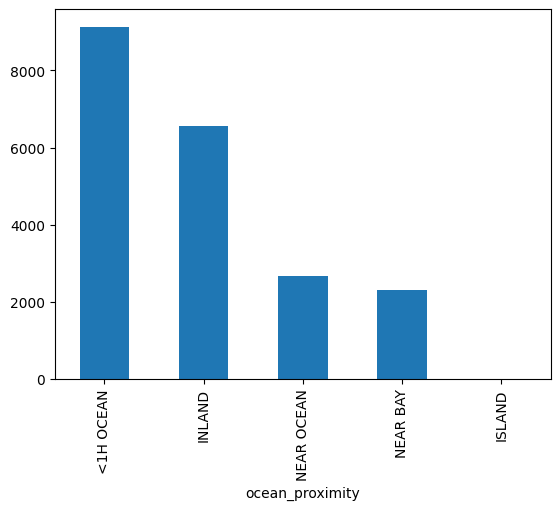

In [4]:
housing.ocean_proximity.value_counts().plot(kind="bar")
print(housing.ocean_proximity.value_counts())

##  3.1 Ocean Proximity Distribution

From the bar chart:
- Most houses are **<1H OCEAN**
- Very few belong to **ISLAND**

This shows class imbalance in location categories.

In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 3.2 Statistical Summary

The summary statistics provide insights into feature distributions:

- Wide variation in numerical features such as total rooms and population  
- Presence of large maximum values indicates potential outliers  
- Median values differ significantly from means in some features  

These observations suggest the need for:
- Feature scaling  
- Outlier handling  

# 4. Data Visualization

Visualizing the data helps in understanding feature distributions, detecting skewness, and identifying outliers.

Histograms are used to analyze:
- Distribution of numerical features  
- Presence of extreme values  
- Data spread across different variables  

This step is essential before applying machine learning models.

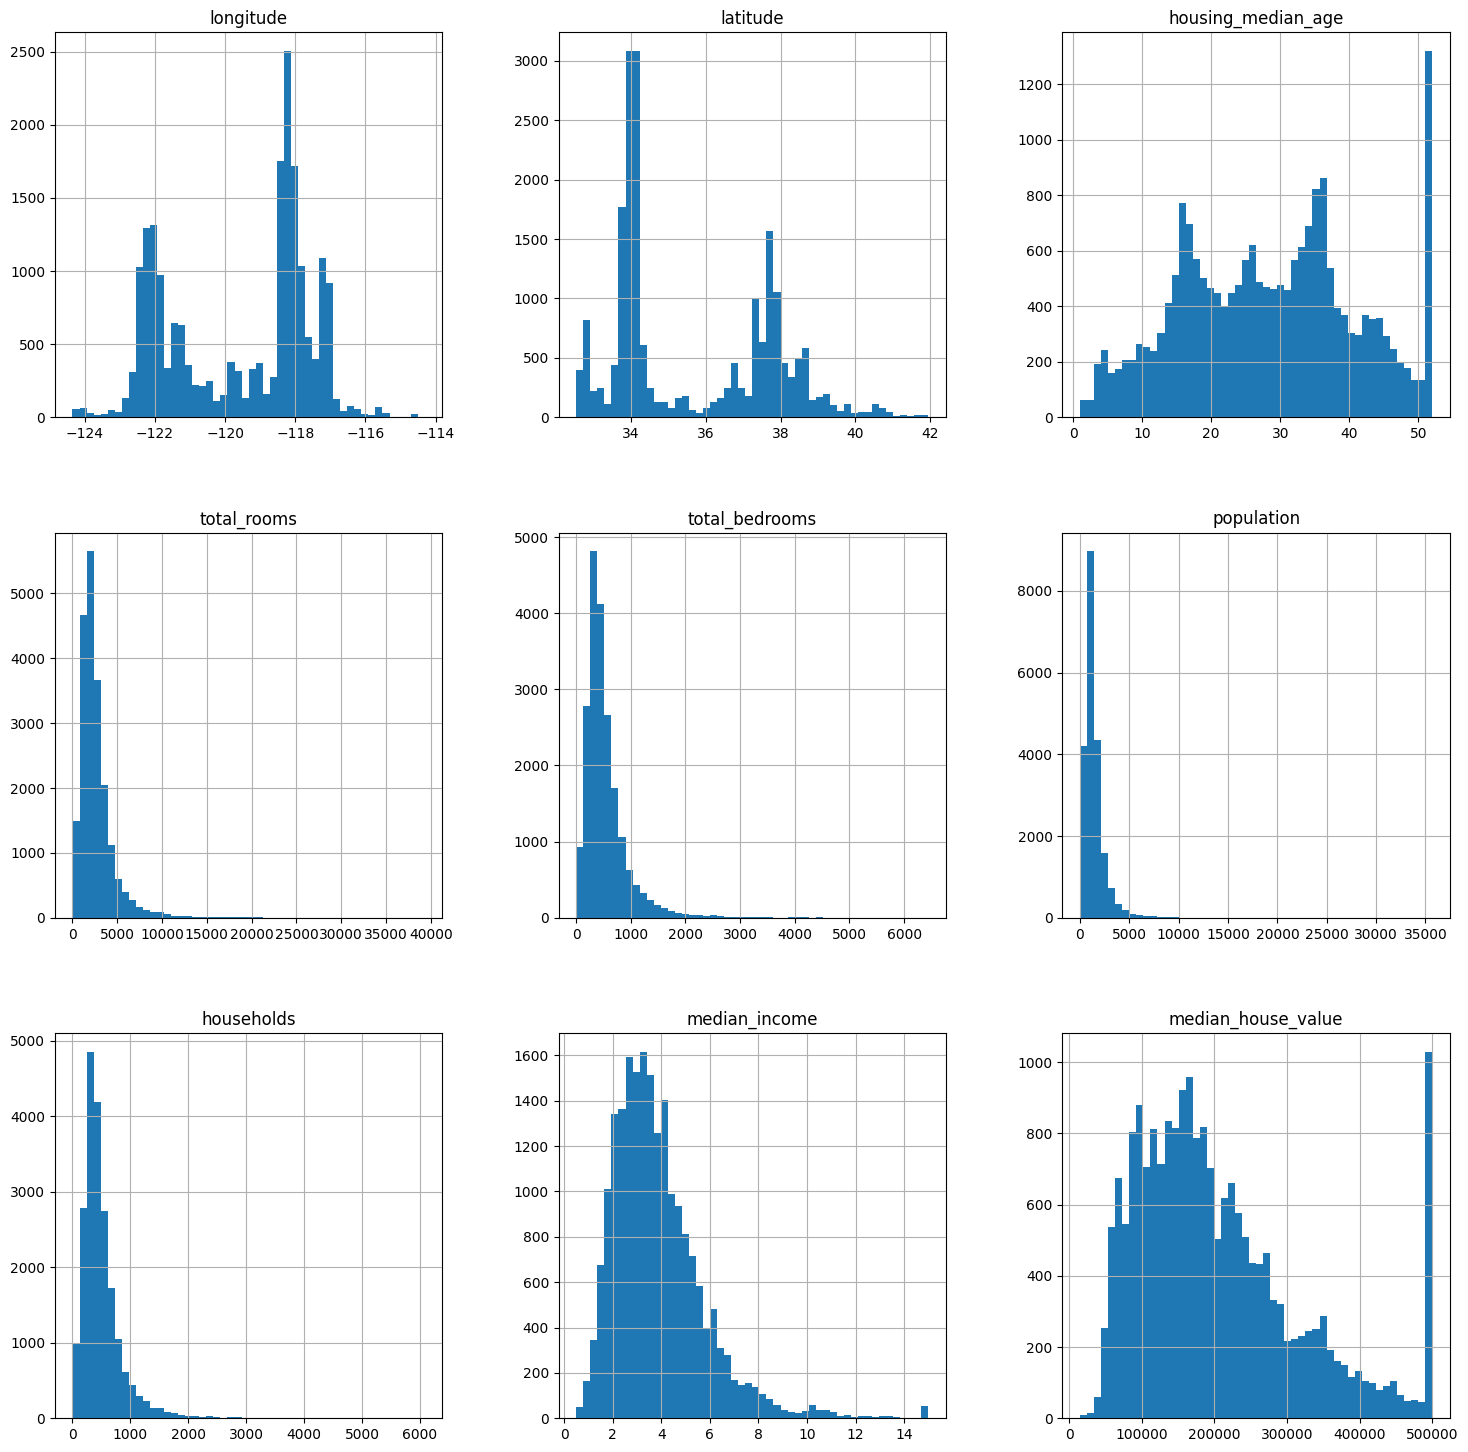

In [6]:
%matplotlib inline
housing.hist(bins=50,figsize=(18,18))
plt.show()

## 4.1 Feature Distribution Analysis
Histograms help us identify:
- Skewness  
- Outliers  
- Data spread  

This is crucial before applying ML models.

0 longitude
1 latitude
2 housing_median_age
3 total_rooms
4 total_bedrooms
5 population
6 households
7 median_income


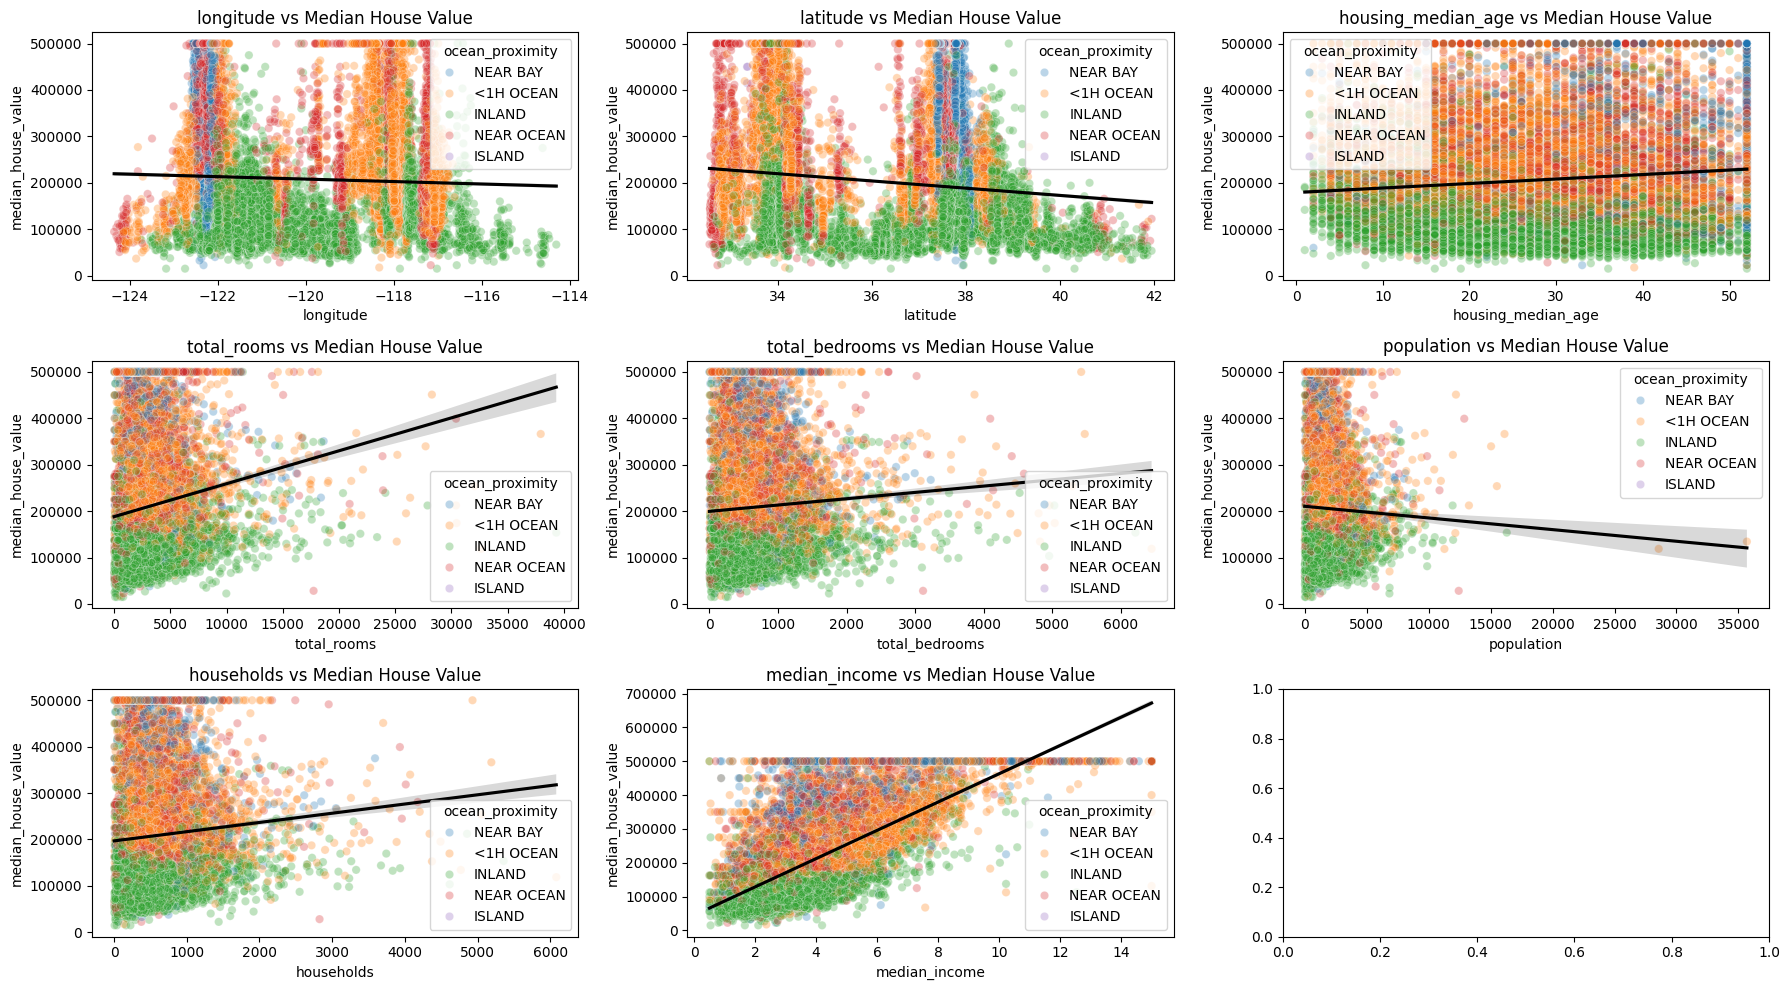

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18,10))
axes = axes.flatten()
for i, col in enumerate(housing.columns[:-2]):
    print(i,col)
    sns.scatterplot(
        data=housing,
        x=col,
        y="median_house_value",
        hue="ocean_proximity",
        alpha=0.3,
        ax=axes[i]
    )
    
    sns.regplot(
        data=housing,
        x=col,
        y="median_house_value",
        scatter=False,
        ax=axes[i],
        color="black"
    )
    
    axes[i].set_title(f"{col} vs Median House Value")

plt.tight_layout()
plt.show()

## 4.2 Key Observations

- **Median Income** has the strongest positive correlation  
- **Total Rooms** also shows a clear trend  
- Other features have weaker impact  

👉 Conclusion: Income is the most important feature most influential feature.  
- Other features show weaker relationships compared to income and rooms.

# 5.💰 Income Analysis

Income plays a crucial role in house pricing.

We analyze its distribution to:
- Detect skewness
- Prepare for stratified sampling




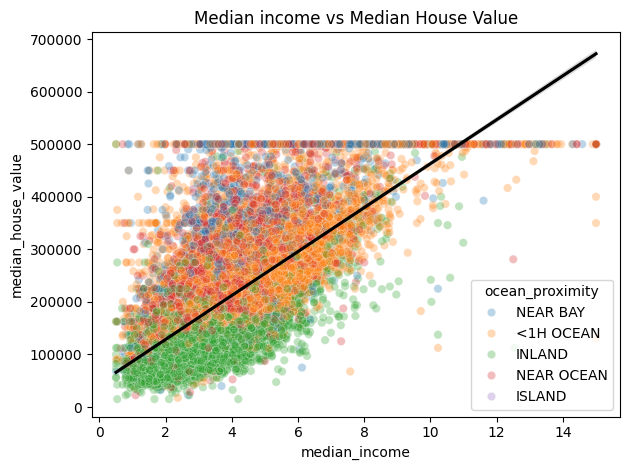

In [8]:
sns.scatterplot(
    data=housing,
    x="median_income",
    y="median_house_value",
    hue="ocean_proximity",
    alpha=0.3,
)

sns.regplot(
    data=housing,
    x="median_income",
    y="median_house_value",
    scatter=False,
    color="black"
)
plt.title(f"Median income vs Median House Value")

plt.tight_layout()
plt.show()

***Median income shows a strong positive correlation with house values***

Text(0.5, 1.0, 'Median Income Distribution')

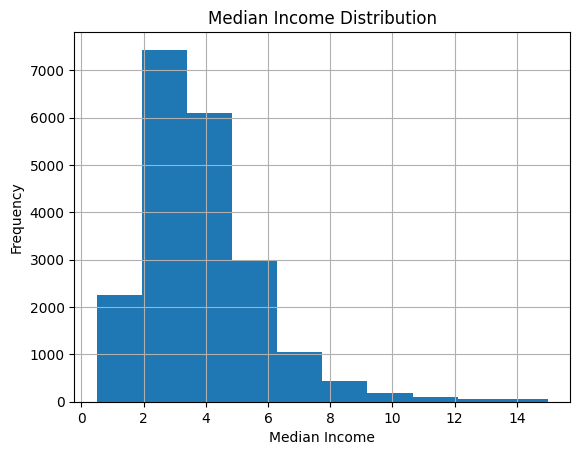

In [9]:
# median Income look like an Imp feature
housing["median_income"].hist()
plt.xlabel("Median Income")
plt.ylabel("Frequency")
plt.title("Median Income Distribution")

<Axes: xlabel='income_cat'>

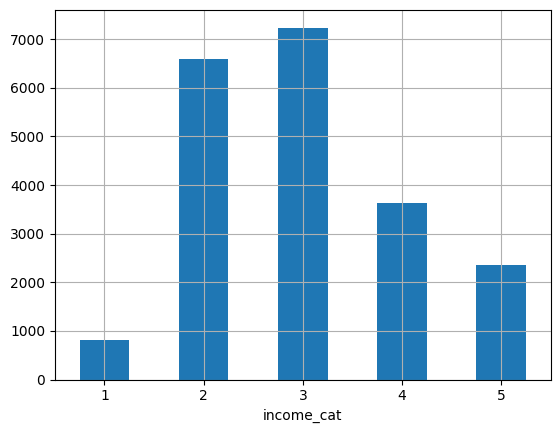

In [10]:
#dividing the income category to limit the number income category
housing["income_cat"] = pd.cut(housing["median_income"],
                             bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
                             labels=[1, 2, 3, 4, 5])
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)  

### Income Categories

We divide median income into discrete categories.

This allows:
- Balanced sampling  
- Better representation of different income levels  
- More reliable model performance  

# 6. Stratified Spliting Sampling ⚖️

We create income categories to:
- Maintain distribution in train & test sets  
- Avoid bias  

This ensures better model performance.

Income strongly affects house price → so we must keep income distribution balanced → income_cat helps do stratified sampling.

In [11]:
split = StratifiedShuffleSplit(n_splits=1,test_size=0.8,random_state=29)
for train_index,test_index in split.split(housing,housing["income_cat"]):
    st_train = housing.loc[train_index]
    st_test = housing.loc[test_index]
st_test.to_csv("Housing_Test.csv")
st_train.to_csv("Housing_Train.csv")

**as seen above the proportions are maintained in the test set using stratified sampling**<br>
**[why stratified?]** because the feature-space are less and also because its a mid-sized dataset & we don't want to miss out any class

In [12]:
# experimenting: with random sampling now
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.8, random_state=42)
def income_cat_proportions(data) :
    return data['income_cat'].value_counts() / len(data)

comparing_props= pd.DataFrame({
"Overall Props" :income_cat_proportions(housing),
"Random": income_cat_proportions(test_set),
"Stratified" :income_cat_proportions(st_test)}).sort_index()
comparing_props["Random % error"]=100*comparing_props["Random"]/comparing_props["Overall Props"] -100
comparing_props["Stratified % error"]=100*comparing_props["Stratified"]/comparing_props["Overall Props"] -100
comparing_props

,Overall Props,Random,Stratified,Random % error,Stratified % error
income_cat,,,,,
1,0.039826,0.038941,0.039850,-2.220195,0.060827
2,0.318847,0.320615,0.318859,0.554627,0.003799
3,0.350581,0.350230,0.350594,-0.100193,0.003455
4,0.176308,0.176478,0.176296,0.096180,-0.006870
5,0.114438,0.113735,0.114402,-0.613887,-0.031753


### Sampling Comparison

We compare:
- Original dataset distribution  
- Random sampling  
- Stratified sampling  

Observation:
Stratified sampling preserves the distribution of income categories more accurately than random sampling.

Conclusion:
Stratified sampling leads to more reliable and unbiased model evaluation.

In [13]:
st_train.drop("income_cat",axis=1,inplace=True)
st_test.drop("income_cat",axis=1,inplace=True)

# 7. Geographical Visualization

Since the dataset contains geographical features (latitude and longitude), we visualize the data spatially.

This helps in:
- Understanding regional distribution of housing  
- Identifying high-value areas  
- Detecting location-based patterns  

We plot the data on a California map with:
- Point size representing population  
- Color representing median income  

<Axes: xlabel='longitude', ylabel='latitude'>

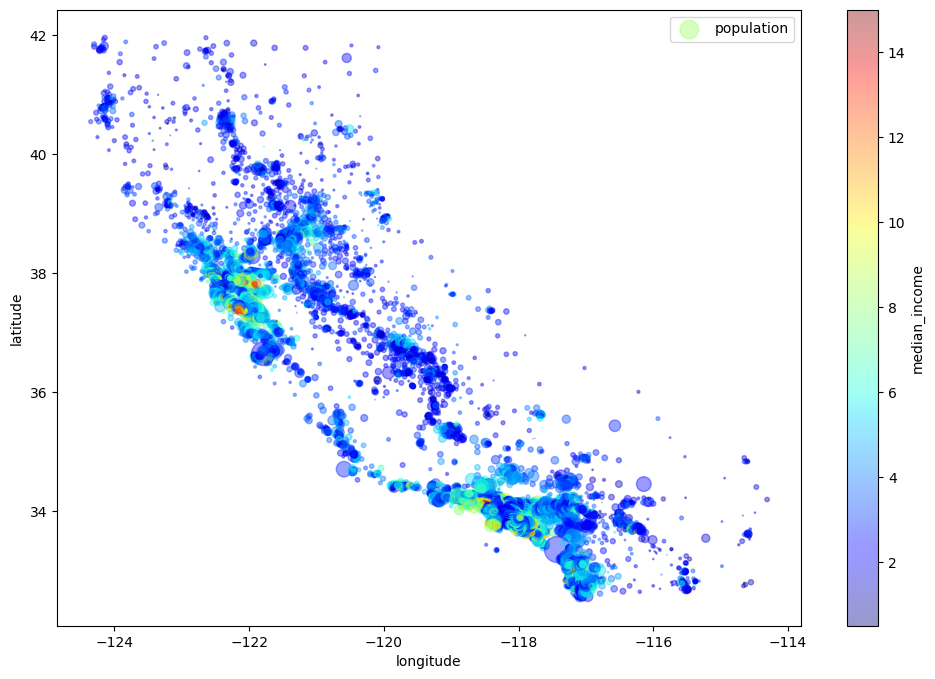

In [14]:
housing.plot(kind="scatter",x="longitude",y="latitude",alpha=0.4,
             s=housing["population"]/100,label="population",
            c="median_income",cmap=plt.get_cmap("jet"),figsize=(12,8),sharex=False)

### Downloading California Map Image

In [15]:
 !wget https://www.pngplay.com/wp-content/uploads/12/California-Map-Background-PNG-Image.png -O california.png

--2026-04-07 17:26:57--  https://www.pngplay.com/wp-content/uploads/12/California-Map-Background-PNG-Image.png
Resolving www.pngplay.com (www.pngplay.com)... 174.142.205.102
Connecting to www.pngplay.com (www.pngplay.com)|174.142.205.102|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19190 (19K) [image/png]
Saving to: ‘california.png’

california.png      100%[===================>]  18.74K  --.-KB/s    in 0s      

2026-04-07 17:26:58 (213 MB/s) - ‘california.png’ saved [19190/19190]



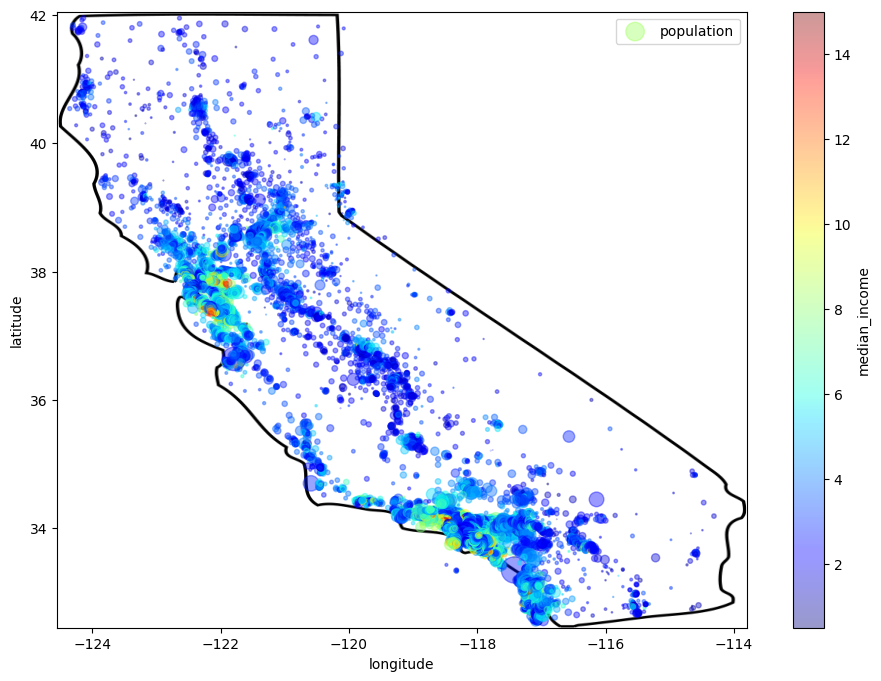

In [16]:
import matplotlib.image as mpimg
ax =housing.plot(kind="scatter",x="longitude",y="latitude",alpha=0.4,
             s=housing["population"]/100,label="population",
            c="median_income",cmap=plt.get_cmap("jet"),figsize=(12,8),sharex=False)
california_map = mpimg.imread("/kaggle/working/california.png")
plt.imshow(california_map, extent=[-124.55,-113.8, 32.45, 42.05])

### Geographical Insights

From the map visualization:

- High-income regions are concentrated near coastal areas  
- Inland regions tend to have lower income levels  
- Population density varies significantly across regions  

Conclusion:
Location plays a significant role in determining house prices.


### **Looking for Correlations <br>(Pearson•s Distance Correlation equation)**


# 8. Correlation Analysis

We compute correlations between features to identify relationships with the target variable.

Correlation analysis helps in:
- Identifying important predictors  
- Understanding feature dependencies  
- Reducing irrelevant features  

In [17]:
housing.corr(numeric_only=True).median_income.sort_values(ascending=False)

median_income         1.000000
median_house_value    0.688075
total_rooms           0.198050
households            0.013033
population            0.004834
total_bedrooms       -0.007723
longitude            -0.015176
latitude             -0.079809
housing_median_age   -0.119034
Name: median_income, dtype: float64

### Correlation Insights

- Median income has the highest positive correlation with house value (~0.68)  
- Total rooms shows moderate correlation  
- Latitude and longitude have weak negative correlation  

Conclusion:
Median income is the strongest predictor for house prices.

array([[<Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>],
       [<Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>],
       [<Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>]], dtype=object)

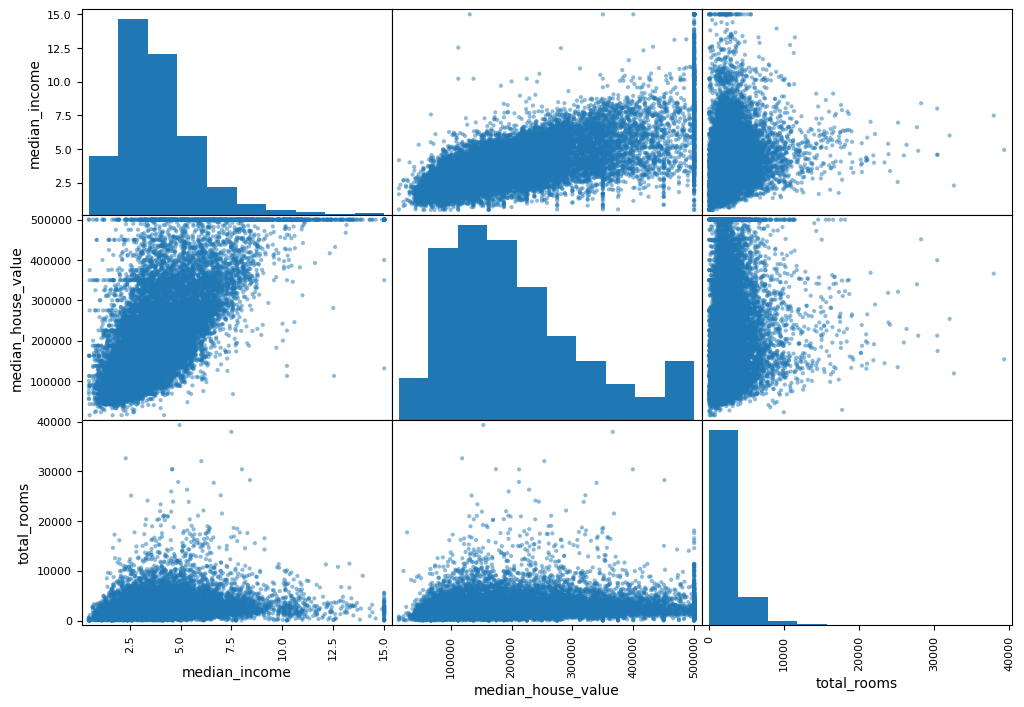

In [18]:
imp_feature = ["median_income","median_house_value","total_rooms"]
scatter_matrix(housing[imp_feature],figsize=(12,8))

### Feature Interaction Analysis

We use a scatter matrix to visualize relationships between key features.

This helps in:
- Observing pairwise relationships  
- Detecting patterns and trends  
- Identifying potential multicollinearity .

# 9. Feature Engineering

Feature engineering involves creating new features from existing data to improve model performance.

This step helps:
- Capture hidden relationships  
- Improve predictive power  
- Enhance model understanding  

In [19]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

In [20]:
housing.corr(numeric_only=True).median_income.sort_values(ascending=False)

median_income               1.000000
median_house_value          0.688075
rooms_per_household         0.326895
total_rooms                 0.198050
population_per_household    0.018766
households                  0.013033
population                  0.004834
total_bedrooms             -0.007723
longitude                  -0.015176
latitude                   -0.079809
housing_median_age         -0.119034
bedrooms_per_room          -0.615661
Name: median_income, dtype: float64

### Impact of Feature Engineering

After adding new features:

- rooms_per_household shows improved correlation  
- bedrooms_per_room reveals a strong negative relationship  
- Overall feature relevance has improved  

Conclusion:
Feature engineering enhances model performance by capturing better relationships in the data.

In [21]:
housing.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967,-0.027540,0.092657,0.002476
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160,0.106389,-0.113815,0.002366
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623,-0.153277,0.136089,0.013191
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153,0.133798,-0.187900,-0.024581
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,0.001538,0.084238,-0.028355
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650,-0.072213,0.035319,0.069863
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843,-0.080598,0.065087,-0.027309
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075,0.326895,-0.615661,0.018766
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000,0.151948,-0.255880,-0.023737
rooms_per_household,-0.027540,0.106389,-0.153277,0.133798,0.001538,-0.072213,-0.080598,0.326895,0.151948,1.000000,-0.416952,-0.004852


In [22]:
df=housing
housing.drop("income_cat",axis=1)
housing.describe().iloc[:,-3:]

,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20433.000000,20640.000000
mean,5.429000,0.213039,3.070655
std,2.474173,0.057983,10.386050
min,0.846154,0.100000,0.692308
25%,4.440716,0.175427,2.429741
50%,5.229129,0.203162,2.818116
75%,6.052381,0.239821,3.282261
max,141.909091,1.000000,1243.333333


# 10. Data Preparation for Machine Learning

Before training models, we prepare the dataset by separating features and target variables.

- Features (X): All input variables  
- Target (y): median_house_value  

This ensures that models learn to predict the target from input features.

In [23]:
housing = st_train.drop("median_house_value", axis=1)
housing_labels = st_train["median_house_value"]

In [24]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4128 entries, 11258 to 11134
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           4128 non-null   float64
 1   latitude            4128 non-null   float64
 2   housing_median_age  4128 non-null   float64
 3   total_rooms         4128 non-null   float64
 4   total_bedrooms      4096 non-null   float64
 5   population          4128 non-null   float64
 6   households          4128 non-null   float64
 7   median_income       4128 non-null   float64
 8   ocean_proximity     4128 non-null   object 
dtypes: float64(8), object(1)
memory usage: 322.5+ KB


In [25]:
housing.isnull().sum()
# total_bedrooms  has 45 null value 

longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms        32
population             0
households             0
median_income          0
ocean_proximity        0
dtype: int64

# 11.🧹 Data Cleaning
- Missing values in `total_bedrooms` are handled using median imputation  
- Ensures no data loss and maintains consistency

In [26]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity",axis=1)
X=imputer.fit_transform(housing_num)
housing_tr = pd.DataFrame(X,columns=housing_num.columns)

### Handling Missing Values

The dataset contains missing values in the `total_bedrooms` feature.

To address this:
- We use median imputation  
- This preserves the distribution without introducing bias  

Handling missing values is essential to ensure model stability.

In [27]:
#cross-Check
housing_tr.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

### Categorical Encoding

Machine learning models require numerical input.

The categorical feature `ocean_proximity` is converted into numerical format using One-Hot Encoding.

This creates separate binary columns for each category..

In [28]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
cat_encoder = OneHotEncoder()
housing_cat = housing[["ocean_proximity"]]
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot.toarray()

# get category names
cat_cols = cat_encoder.get_feature_names_out(["ocean_proximity"])

# convert to dataframe
housing_cat_df = pd.DataFrame(
    housing_cat_1hot.toarray(),
    columns=cat_cols,
    index=housing.index
)


# drop original column
housingCAT = housing.drop("ocean_proximity", axis=1)
# join with original data
housingCAT=housingCAT.join(housing_cat_df)
housingCAT


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
11258,-117.97,33.81,26.0,4022.0,1081.0,2457.0,1001.0,2.8042,1.0,0.0,0.0,0.0,0.0
2181,-119.92,36.77,18.0,1422.0,243.0,702.0,230.0,3.6204,0.0,1.0,0.0,0.0,0.0
19169,-122.70,38.39,16.0,4922.0,1211.0,2557.0,1088.0,2.0915,1.0,0.0,0.0,0.0,0.0
6531,-118.07,34.07,31.0,1370.0,284.0,1062.0,277.0,3.5156,1.0,0.0,0.0,0.0,0.0
11977,-117.50,34.00,15.0,1929.0,317.0,1237.0,316.0,4.4063,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
808,-122.03,37.62,32.0,2964.0,547.0,1472.0,527.0,4.2468,0.0,0.0,0.0,1.0,0.0
12904,-121.34,38.61,11.0,1716.0,404.0,722.0,415.0,2.0926,0.0,1.0,0.0,0.0,0.0
6791,-118.15,34.08,44.0,1053.0,251.0,941.0,256.0,3.1250,1.0,0.0,0.0,0.0,0.0
13179,-117.76,33.98,3.0,9662.0,1385.0,2497.0,856.0,6.7172,1.0,0.0,0.0,0.0,0.0


### Encoding Results

- The categorical feature is successfully transformed  
- New binary columns represent each category  
- The dataset is now fully numerical  

This allows models to process categorical information effectively.

### Custom Feature Transformer

We define a custom transformer to automatically generate engineered features.

This ensures:
- Consistency across training and testing  
- Integration into the pipeline  
- Reusability of feature engineering logic  

In [29]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# column indexes
rooms_ix, bedrooms_ix, population_ix, household_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, household_ix]
        population_per_household = X[:, population_ix] / X[:, household_ix]
        bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
        return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
    

# 12. Data Preprocessing Pipeline

To streamline preprocessing, we build a pipeline that automates:

- Missing value handling  
- Feature engineering  
- Feature scaling  
- Categorical encoding  

Benefits of using pipelines:
- Cleaner code  
- Reproducibility  
- Reduced risk of data leakage  

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# numeric and categorical columns
num_attribs = list(housing.drop(["ocean_proximity"], axis=1))
cat_attribs = ["ocean_proximity"]

# numeric pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("scaler", StandardScaler())
])

# full pipeline
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs)
])

### Final Prepared Dataset

After applying the pipeline:

- All features are numerical  
- Data is scaled and transformed  
- Feature engineering is applied  

The dataset is now ready for model training.

This structured preprocessing is critical for building robust machine learning models.

In [31]:
# transform data
housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared

array([[ 0.80002817, -0.85526377, -0.19240329, ...,  0.        ,
         0.        ,  0.        ],
       [-0.17144521,  0.52254354, -0.82665427, ...,  0.        ,
         0.        ,  0.        ],
       [-1.55641752,  1.27661376, -0.98521701, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.7103537 , -0.7295854 ,  1.23466141, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.90464838, -0.77613294, -2.01587485, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.81497391, -0.83664475,  0.6796918 , ...,  0.        ,
         0.        ,  0.        ]])

### Pipeline Components

The pipeline consists of:

- SimpleImputer → handles missing values  
- Custom Transformer → adds new features  
- StandardScaler → normalizes numerical data  
- OneHotEncoder → encodes categorical data  

This ensures all preprocessing steps are applied consistently.

# 13. Model Training

We train multiple machine learning models to identify the best-performing algorithm for this dataset.

The models include:

- Linear Models (Linear Regression, Ridge, Lasso)  
- Tree-Based Models (Decision Tree, Extra Trees)  
- Ensemble Models (Random Forest, Gradient Boosting, Bagging)  
- XGBoost  

Using multiple models allows us to compare performance and select the most suitable approach.

In [32]:
#ref : ChatGPT
models = [

    # Ensemble Methods (BEST)
    ensemble.AdaBoostRegressor(),
    ensemble.BaggingRegressor(),
    ensemble.ExtraTreesRegressor(),
    ensemble.GradientBoostingRegressor(),
    ensemble.RandomForestRegressor(),

    # Gaussian Processes
    gaussian_process.GaussianProcessRegressor(),

    # Linear Models (GLM)
    linear_model.LinearRegression(),
    linear_model.Ridge(),
    linear_model.Lasso(),
    linear_model.ElasticNet(),
    linear_model.SGDRegressor(),
    linear_model.PassiveAggressiveRegressor(),

    # Nearest Neighbor
    neighbors.KNeighborsRegressor(),

    # SVM
    svm.SVR(),
    svm.NuSVR(),
    svm.LinearSVR(),

    # Trees
    tree.DecisionTreeRegressor(),
    tree.ExtraTreeRegressor(),

    # XGBoost (VERY BEST)
    XGBRegressor()
]

In [33]:
results = []

Housing_test_df     = pd.read_csv("/kaggle/working/Housing_Test.csv")
housing_Predict     = Housing_test_df.copy()
Housing_test_labels = Housing_test_df["median_house_value"]
Housing_test_df.drop("median_house_value",axis=1,inplace=True)


In [34]:
housing_Predict_Prepared_Pipeline = full_pipeline.transform(Housing_test_df)
housing_Predict_Prepared = pd.DataFrame(housing_Predict_Prepared_Pipeline)

## 13.1 Training Strategy

Each model is trained using the prepared dataset.

For evaluation:
- Predictions are generated on the test dataset  
- Performance is measured using R² score  

This ensures a fair comparison across all models.

In [35]:
!mkdir Models
for model in models:
    name = model.__class__.__name__

    # Fit Model 
    model.fit(housing_prepared, housing_labels)

    # Give Test File For Predict Value
    y_pred = model.predict(housing_Predict_Prepared)

    # Getting Score For Result
    acc = r2_score(Housing_test_labels  , y_pred)

    # Save Predict Values
    housing_Predict[name]=y_pred

    #Store Result 
    results.append([name, acc])

    # deployment Of Model 
    joblib.dump(model,f"Models/{name}_{acc * 100:.2f}.pkl")
    print(name, ":", acc)

AdaBoostRegressor : 0.5432694788522824
BaggingRegressor : 0.7455376024226263
ExtraTreesRegressor : 0.7752804760243065
GradientBoostingRegressor : 0.7752458043964509
RandomForestRegressor : 0.7709270317562602
GaussianProcessRegressor : -0.36188854351963484
LinearRegression : -4.664455615828039
Ridge : -4.6831844205343165
Lasso : -4.667077349273361
ElasticNet : -2.9058703814040445
SGDRegressor : -6.066946162675202


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.356e+11, tolerance: 5.478e+09
  model = cd_fast.enet_coordinate_descent(


PassiveAggressiveRegressor : -4.264877389739203
KNeighborsRegressor : 0.7062401192854986
SVR : -0.07734565742966826
NuSVR : -0.024524391192841444
LinearSVR : -3.0642153532265546
DecisionTreeRegressor : 0.5629325469677747
ExtraTreeRegressor : 0.4704029159129298
XGBRegressor : 0.7976405648576056


## 13.2 Model Performance Results

The results show a clear distinction between model types:

- Ensemble models perform significantly better  
- Linear models show poor performance (negative R²)  
- Tree-based models provide moderate accuracy  

Top-performing models:
- XGBoost (~0.79)  
- Extra Trees (~0.77)  
- Gradient Boosting (~0.77)  
- Random Forest (~0.77)  

Conclusion:
Ensemble methods are best suited for this dataset.

In [36]:
results_df = pd.DataFrame(results, columns=["Model","Accuracy"])
results_df.sort_values("Accuracy", ascending=False)

,Model,Accuracy
18,XGBRegressor,0.797641
2,ExtraTreesRegressor,0.775280
3,GradientBoostingRegressor,0.775246
4,RandomForestRegressor,0.770927
1,BaggingRegressor,0.745538
12,KNeighborsRegressor,0.706240
16,DecisionTreeRegressor,0.562933
0,AdaBoostRegressor,0.543269
17,ExtraTreeRegressor,0.470403
14,NuSVR,-0.024524


## 13.3 Performance Ranking

After sorting the results:

- XGBoost achieves the highest accuracy  
- Ensemble models dominate the top positions  
- Linear models perform poorly due to inability to capture complex relationships  

This confirms that non-linear models are more effective for this problem.

## 13.4 Saving Predictions

We store model predictions for further analysis.

This allows:
- Comparison across models  
- Visualization of prediction behavior  
- Error analysis  

In [37]:
housing_Predict.to_csv("housing_Predict.csv")
housing_Predict

,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,...,ElasticNet,SGDRegressor,PassiveAggressiveRegressor,KNeighborsRegressor,SVR,NuSVR,LinearSVR,DecisionTreeRegressor,ExtraTreeRegressor,XGBRegressor
0,9515,-123.20,39.16,14.0,1908.0,484.0,1195.0,467.0,1.7929,82300.0,...,149324.491998,145456.531722,136948.535543,149340.0,174894.473133,188824.827224,5915.0,149300.0,84000.0,99643.265625
1,7114,-118.02,33.92,34.0,2169.0,418.0,1169.0,406.0,3.2222,218700.0,...,206971.420319,192609.683822,177299.247215,181320.0,175106.909231,188962.874584,5915.0,159700.0,191100.0,155970.765625
2,1600,-122.12,37.89,30.0,3227.0,733.0,1260.0,684.0,4.1250,257100.0,...,236854.415680,266904.417515,242409.368119,250360.0,175068.829019,188960.365495,4611.0,225000.0,225000.0,321686.593750
3,3622,-118.45,34.23,15.0,5738.0,1767.0,4620.0,1581.0,2.3584,157600.0,...,175746.469878,190018.197766,175078.269778,212480.0,175056.000676,188968.809170,5915.0,247000.0,445000.0,177884.656250
4,10605,-117.81,33.67,9.0,3279.0,530.0,1447.0,510.0,7.4581,296600.0,...,302036.812831,339553.614580,339228.126022,323420.0,175328.718249,189157.768670,5915.0,275000.0,375700.0,334922.093750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,153,-122.23,37.81,52.0,1433.0,229.0,612.0,213.0,4.7708,314700.0,...,250197.067702,266753.485547,241978.469405,256320.0,175127.618701,189010.089749,4611.0,353400.0,275000.0,291229.593750
16508,11294,-117.92,33.79,35.0,1785.0,288.0,1033.0,297.0,4.5739,190500.0,...,231607.621275,224072.843168,213384.921553,185860.0,175189.678262,189031.990406,5915.0,205800.0,211500.0,204952.187500
16509,20241,-119.24,34.27,32.0,4071.0,888.0,1900.0,874.0,3.2792,220500.0,...,221611.583334,246987.317886,220939.879247,243780.0,175103.101102,188983.649337,4673.0,500001.0,500001.0,260898.562500
16510,4100,-118.37,34.14,21.0,4670.0,1161.0,1914.0,1094.0,3.7986,367700.0,...,240116.303509,268779.949085,244829.403566,258000.0,175139.150849,189015.231499,5915.0,229800.0,500001.0,271174.625000


# 14. Model Optimization 

Although initial results are strong, further improvement is possible.

We apply hyperparameter tuning on top-performing models to:
- Improve accuracy  
- Reduce overfitting  
- Optimize model complexity  

## 14.1 XGBRegressor

In [38]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(housing_prepared, housing_labels)

best_xgb = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}


## 14.2 RandomForestRegressor

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

param_dist_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=8,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(housing_prepared, housing_labels)

best_rf = rf_search.best_estimator_
print("Best Parameters:", rf_search.best_params_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}


## 14.3 GradientBoostingRegressor

In [40]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

param_dist_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    gb,
    param_distributions=param_dist_gb,
    n_iter=8,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

gb_search.fit(housing_prepared, housing_labels)

best_gb = gb_search.best_estimator_
print("Best Parameters:", gb_search.best_params_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}


## 14.4 ExtraTreesRegressor

In [41]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(random_state=42)

param_dist_et = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

et_search = RandomizedSearchCV(
    et,
    param_distributions=param_dist_et,
    n_iter=8,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

et_search.fit(housing_prepared, housing_labels)

best_et = et_search.best_estimator_

print("Best Parameters:", et_search.best_params_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}


# 15. Hyperparameter Tuning Results

We applied hyperparameter tuning to the top-performing models to improve their performance.

Key observations:
- Tuned XGBoost achieved the highest accuracy (~0.81 R²)  
- Gradient Boosting also showed strong improvement  
- Random Forest and Extra Trees improved slightly  

Conclusion:
Hyperparameter tuning significantly enhances model performance, especially for ensemble methods.

In [42]:
from sklearn.metrics import r2_score

models_tuned = {
    "XGB_Tuned": best_xgb,
    "RF_Tuned": best_rf,
    "GB_Tuned": best_gb,
    "ET_Tuned": best_et
}

tuned_results = []

for name, model in models_tuned.items():
    y_pred = model.predict(housing_Predict_Prepared)
    score = r2_score(Housing_test_labels, y_pred)
    tuned_results.append([name, score])
    print(name, ":", score)
    # Save Predict Value
    housing_Predict[name]=y_pred
    #Store Result 
    results.append([name, score])
    # Deployment Of Model 
    joblib.dump(model,f"Models/{name}_{score * 100:.2f}.pkl")
    
tuned_df = pd.DataFrame(tuned_results, columns=["Model", "Accuracy"])
tuned_df.sort_values("Accuracy", ascending=False)

XGB_Tuned : 0.8093433360585834
RF_Tuned : 0.7735202511972056
GB_Tuned : 0.810027510608501
ET_Tuned : 0.7756729503826396


,Model,Accuracy
2,GB_Tuned,0.810028
0,XGB_Tuned,0.809343
3,ET_Tuned,0.775673
1,RF_Tuned,0.773520


## 15.1 Performance After Tuning

After tuning:

- XGBoost remains the best-performing model  
- Gradient Boosting performs nearly as well  
- Tuned models outperform their baseline versions  

This confirms the importance of parameter optimization in machine learning workflows.

In [43]:
results_df=pd.DataFrame(results,columns=["Models","Score"])
results_df.sort_values(by="Score", ascending=False)

,Models,Score
21,GB_Tuned,0.810028
19,XGB_Tuned,0.809343
18,XGBRegressor,0.797641
22,ET_Tuned,0.775673
2,ExtraTreesRegressor,0.775280
3,GradientBoostingRegressor,0.775246
20,RF_Tuned,0.773520
4,RandomForestRegressor,0.770927
1,BaggingRegressor,0.745538
12,KNeighborsRegressor,0.706240


In [44]:
model_list=results_df.Models.tolist()
model_list.insert(0 , "median_house_value")
matrixData=housing_Predict[model_list]
matrixData

,median_house_value,AdaBoostRegressor,BaggingRegressor,ExtraTreesRegressor,GradientBoostingRegressor,RandomForestRegressor,GaussianProcessRegressor,LinearRegression,Ridge,Lasso,...,SVR,NuSVR,LinearSVR,DecisionTreeRegressor,ExtraTreeRegressor,XGBRegressor,XGB_Tuned,RF_Tuned,GB_Tuned,ET_Tuned
0,82300.0,185936.846080,125550.0,116433.00,110645.447761,137136.00,184924.649934,141578.232184,141518.114883,141571.811800,...,174894.473133,188824.827224,5915.0,149300.0,84000.0,99643.265625,126995.046875,131321.872619,107412.197499,122775.208333
1,218700.0,254854.627556,192990.0,183062.00,188174.381645,185818.00,103440.716461,193870.178900,193942.184134,193874.217550,...,175106.909231,188962.874584,5915.0,159700.0,191100.0,155970.765625,172325.687500,183037.454257,187008.232105,182376.510000
2,257100.0,334008.886189,396770.2,313105.05,297886.862894,365881.19,287163.531392,262206.832387,262238.062393,262214.519867,...,175068.829019,188960.365495,4611.0,225000.0,225000.0,321686.593750,299039.125000,359337.980198,310070.769182,320970.876667
3,157600.0,289237.215226,212410.0,187742.00,177698.884469,190865.00,189527.533543,188301.087724,188297.629251,188306.047331,...,175056.000676,188968.809170,5915.0,247000.0,445000.0,177884.656250,176059.062500,191870.955029,183465.339741,205100.125000
4,296600.0,349224.703751,292490.0,333254.05,347553.246931,337032.11,427426.859443,341900.479047,341861.400834,341901.120818,...,175328.718249,189157.768670,5915.0,275000.0,375700.0,334922.093750,345249.625000,331172.960750,354846.171033,319870.745417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,314700.0,328045.114707,257110.0,277419.05,231312.178600,251550.01,146328.836157,266419.027896,266516.731259,266431.770138,...,175127.618701,189010.089749,4611.0,353400.0,275000.0,291229.593750,262643.937500,274136.932520,245499.046476,284413.995417
16508,190500.0,286759.622857,208110.0,192019.00,187553.305643,197247.00,250722.204473,227531.116727,227583.878267,227533.684606,...,175189.678262,189031.990406,5915.0,205800.0,211500.0,204952.187500,188347.140625,189995.510648,190031.901442,189418.083333
16509,220500.0,294558.976744,294810.1,298889.13,286495.772364,273940.05,122135.458853,248786.332185,248696.010834,248762.843814,...,175103.101102,188983.649337,4673.0,500001.0,500001.0,260898.562500,267210.562500,281099.983357,274761.032354,291577.712917
16510,367700.0,330479.605025,284880.1,340603.14,323094.468323,293799.04,324128.771443,268301.137907,268217.335655,268284.741562,...,175139.150849,189015.231499,5915.0,229800.0,500001.0,271174.625000,292036.250000,299905.643263,322593.962622,330513.415833


# 16. Model Performance Visualization

We visualize model performance to compare accuracy across all models.

This helps:
- Quickly identify top models  
- Understand performance gaps  
- Highlight improvements after tuning  

## 16.1 Performance Comparison Insights

- Ensemble models dominate the top positions  
- Tuned models outperform baseline models  
- Linear models perform poorly due to lack of complexity  

Conclusion:
Non-linear ensemble methods are best suited for this dataset.

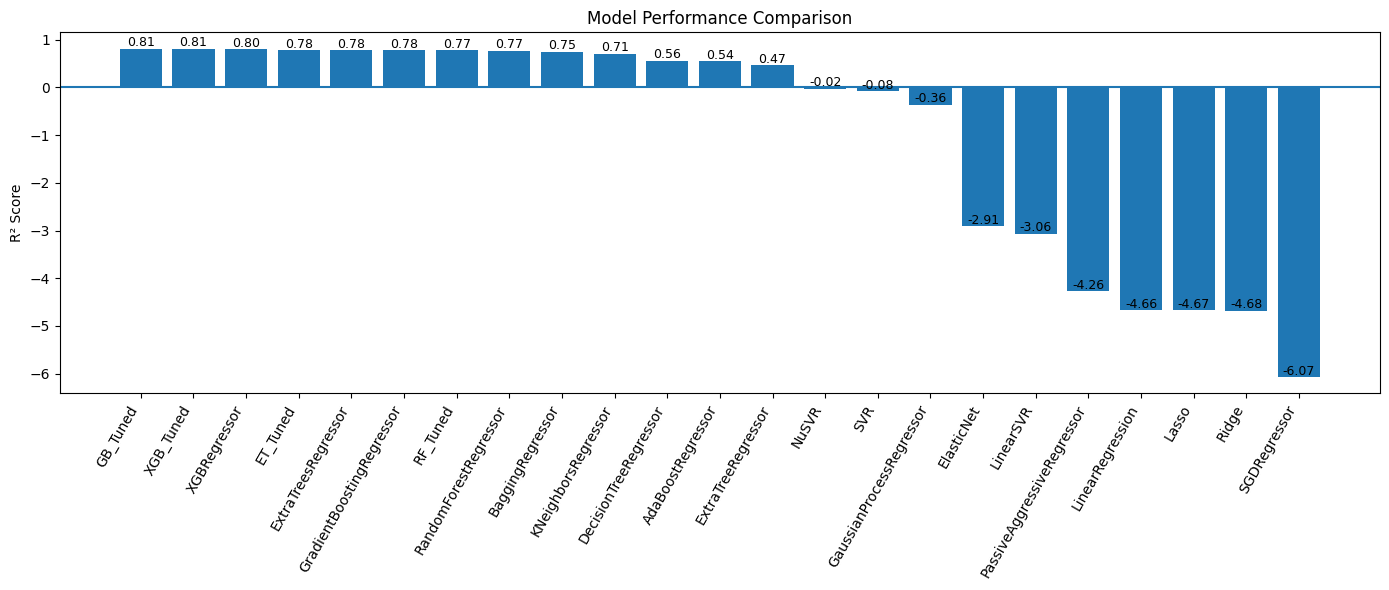

In [45]:
# Sort results
results_sorted = results_df.sort_values("Score", ascending=False)

plt.figure(figsize=(14,6))

bars = plt.bar(results_sorted["Models"], results_sorted["Score"])

# Rotate labels properly
plt.xticks(rotation=60, ha="right")

# Labels & title
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

# Add values on top of bars
for i, v in enumerate(results_sorted["Score"]):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)

# Add horizontal line at 0 (important for negative models)
plt.axhline(0)

plt.tight_layout()
plt.show()

## 16.2 Positive vs Negative Performance

We separate models based on performance:

- Positive R² → useful models  
- Negative R² → poor models  

This provides a clearer understanding of model quality.

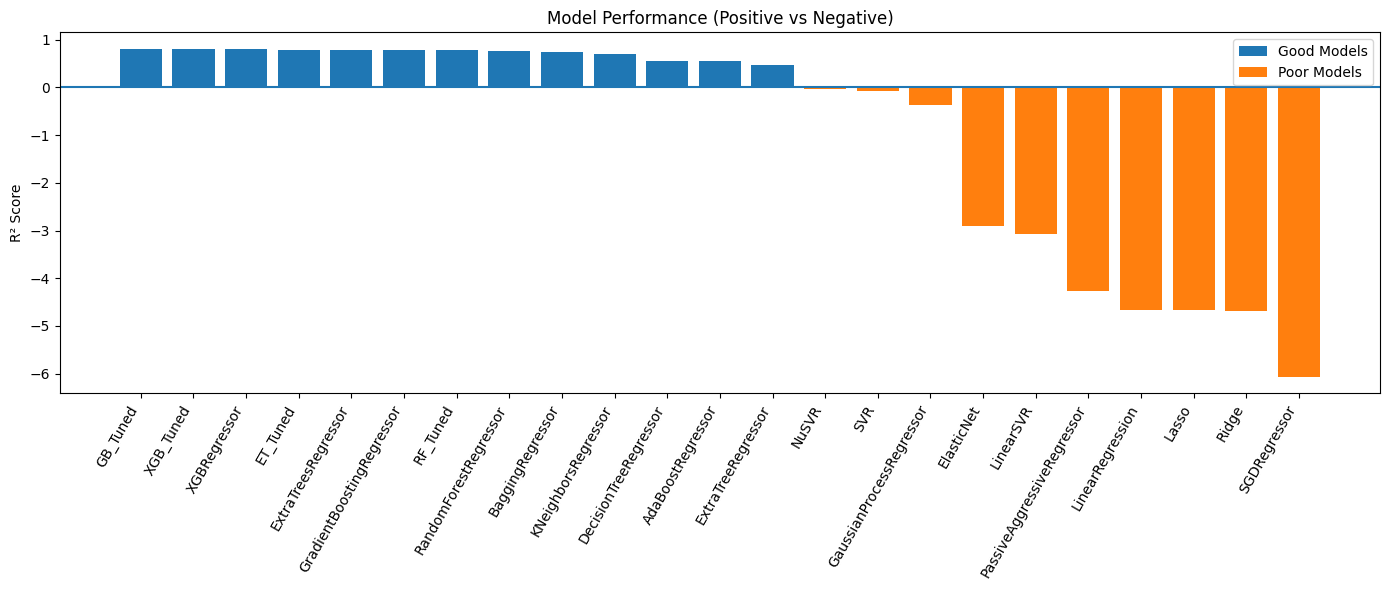

In [46]:
good_models = results_sorted[results_sorted["Score"] > 0]
bad_models = results_sorted[results_sorted["Score"] <= 0]

plt.figure(figsize=(14,6))

# Plot separately
plt.bar(good_models["Models"], good_models["Score"], label="Good Models")
plt.bar(bad_models["Models"], bad_models["Score"], label="Poor Models")

plt.xticks(rotation=60, ha="right")
plt.ylabel("R² Score")
plt.title("Model Performance (Positive vs Negative)")

plt.axhline(0)
plt.legend()

plt.tight_layout()
plt.show()

## 16.3 Predictions vs Actual Values

We compare predicted values with actual values for the best-performing model.

A well-performing model should:
- Produce predictions close to actual values  
- Follow a diagonal trend  

This visualization helps validate model accuracy.

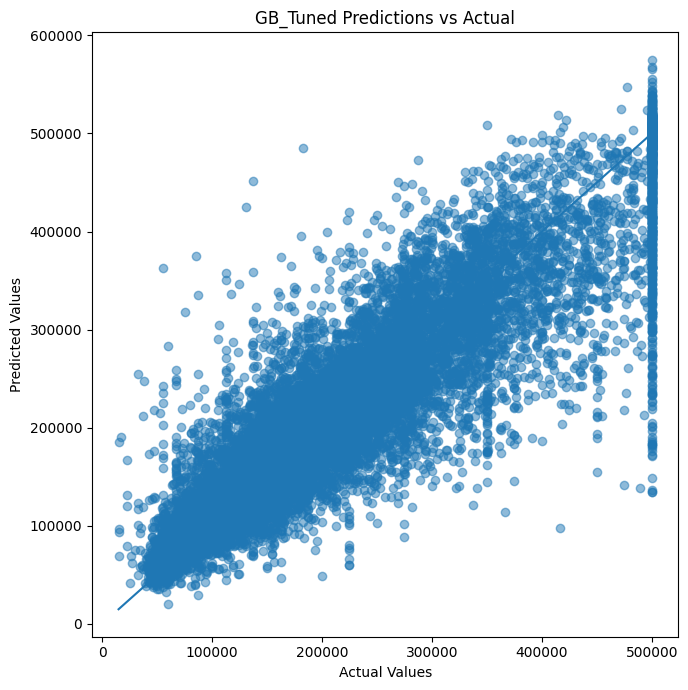

In [47]:
best_model_name = results_df.sort_values("Score", ascending=False).iloc[0]["Models"]

plt.figure(figsize=(7,7))

plt.scatter(matrixData["median_house_value"], matrixData[best_model_name], alpha=0.5)

plt.plot(
    [matrixData["median_house_value"].min(), matrixData["median_house_value"].max()],
    [matrixData["median_house_value"].min(), matrixData["median_house_value"].max()]
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"{best_model_name} Predictions vs Actual")

plt.tight_layout()
plt.show()

## 16.4 Prediction Error Analysis

Instead of exact correctness, we analyze prediction errors.

- Error = |Predicted − Actual|  
- Lower error indicates better performance  

This provides a more accurate evaluation for regression tasks.

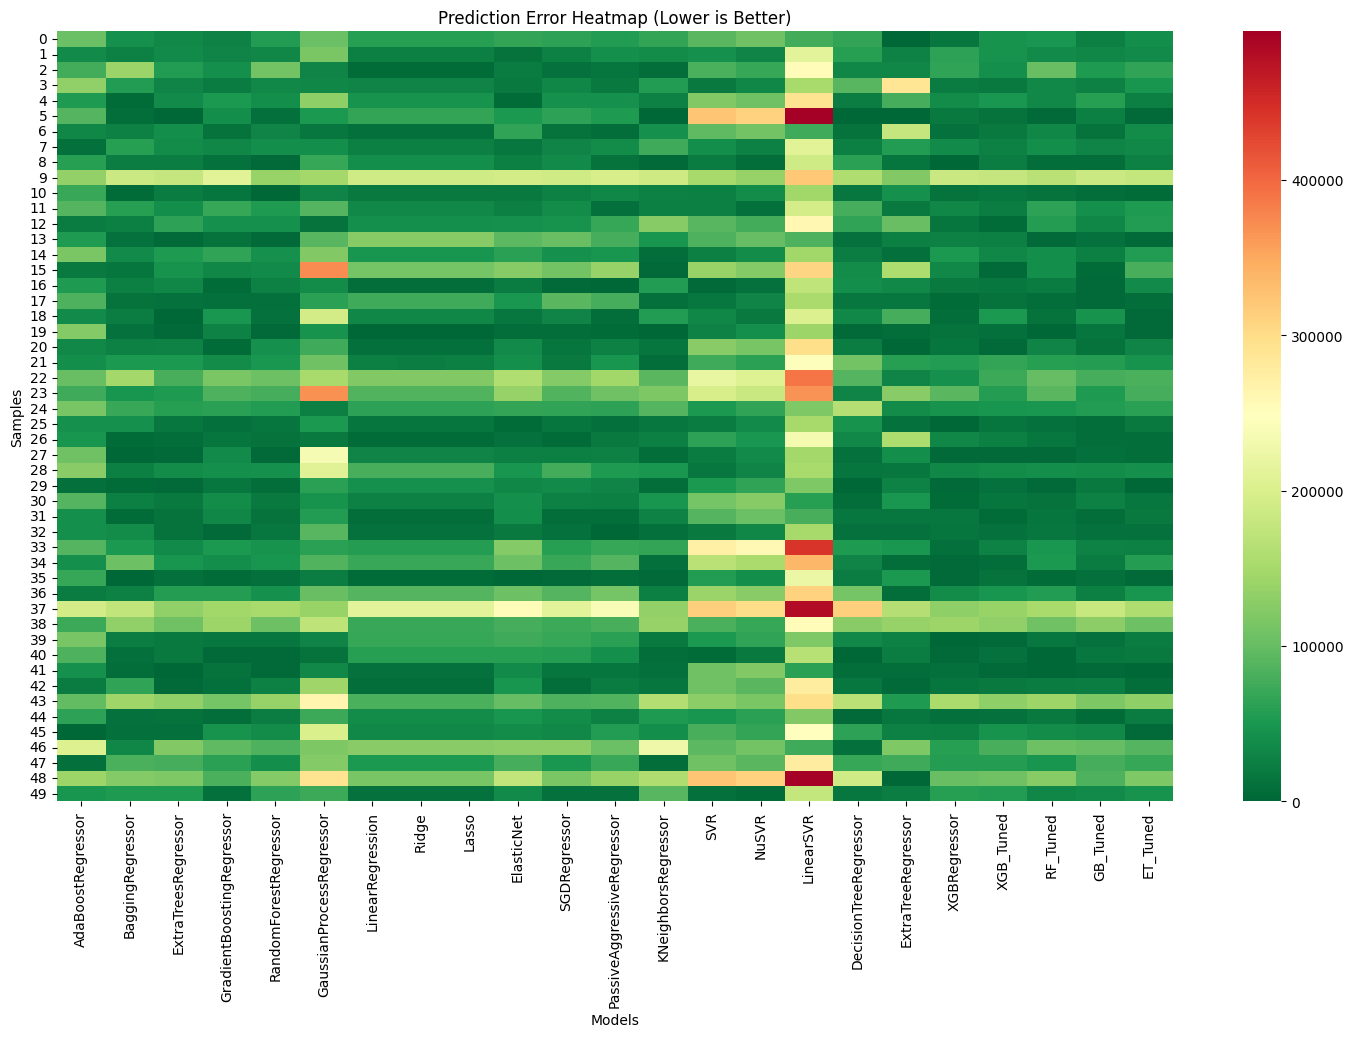

In [48]:

error_matrix = matrixData.drop(columns=["median_house_value"]).sub(
    matrixData["median_house_value"], axis=0
).abs()

plt.figure(figsize=(18,10))

sns.heatmap(
    error_matrix.head(50),
    cmap="RdYlGn_r",   
    cbar=True
)

plt.title("Prediction Error Heatmap (Lower is Better)")
plt.xlabel("Models")
plt.ylabel("Samples")

plt.show()

## 16.5 Model Agreement Analysis

We evaluate how many models perform well for each sample using an error threshold.

This helps identify:
- Easy samples (many models agree)  
- Difficult samples (models disagree)  

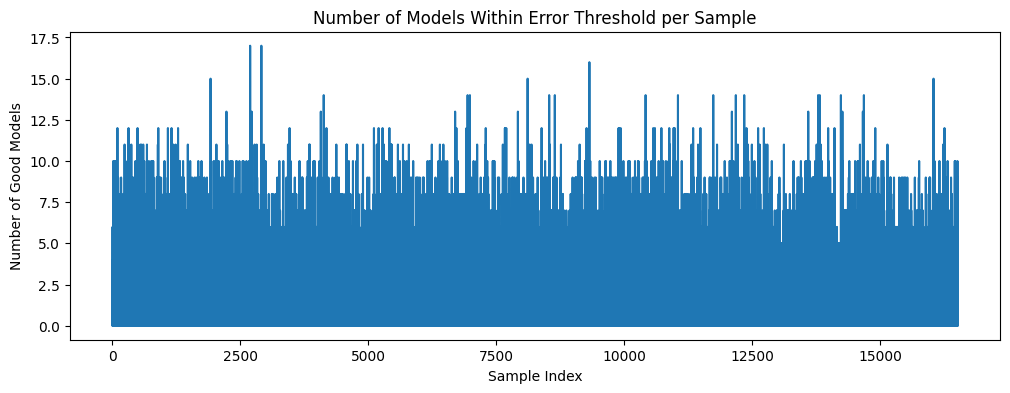

In [49]:
# define tolerance (adjust based on dataset scale)
tolerance = 5000  

# calculate absolute error
error_matrix = matrixData.drop(columns=["median_house_value"]).sub(
    matrixData["median_house_value"], axis=0
).abs()

# count models within tolerance
row_good = (error_matrix < tolerance).sum(axis=1)

plt.figure(figsize=(12,4))
plt.plot(row_good)

plt.title("Number of Models Within Error Threshold per Sample")
plt.xlabel("Sample Index")
plt.ylabel("Number of Good Models")

plt.show()

# 17. Final Conclusion

This project demonstrates a complete machine learning pipeline for housing price prediction.

Key takeaways:

- Median income is the most influential feature  
- Feature engineering improves model performance  
- Ensemble models outperform linear models  
- Hyperparameter tuning further enhances accuracy  
- XGBoost achieved the best performance (~0.81 R²)  

### Overall Summary

The workflow successfully covers:
- Data analysis  
- Feature engineering  
- Model training and evaluation  
- Performance optimization  
- Model deployment readiness  

This project reflects a real-world machine learning pipeline.